In [354]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,create_df_by_type_nostart
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,calculate_speed
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
G8CK_train_df = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\G8CK_train_df.h5")
G8CK1_train_df = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\G8CK1_train_df.h5")
J701_train_df = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\J701_train_df.h5") 

In [352]:
train_oa = pd.concat([G8CK1_train_df,G8CK_train_df,J701_train_df])
train_oa.time =train_oa.len/60
train_oa =train_oa[train_oa.date_index>=-4]
df_tortuosity(train_oa)

In [358]:
train_oa = train_oa.reset_index()

In [6]:
with pd.HDFStore(r"D:\obstacle_avoidance\metadata\SFN\data\light_train.h5",) as hdf:
    # This prints a list of all group names:
    print(hdf.keys())

['/', '/table', '/w']


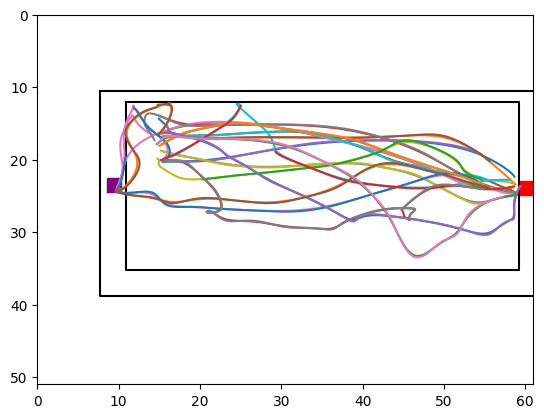

In [34]:
data = train_oa[(train_oa.animal=='G8CK1RT') &(train_oa.date_index==-4) & (train_oa.start=='top')&(train_oa.odd=='left')]
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

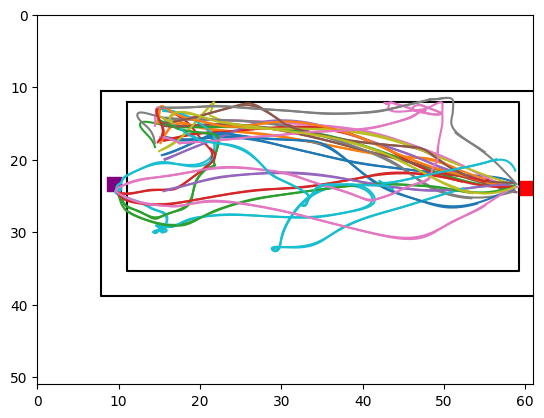

In [35]:
data = train_oa[(train_oa.animal=='G8CK1RT') &(train_oa.date_index==-1) & (train_oa.start=='top')&(train_oa.odd=='left')]
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [57]:
list(range(9,59,5))

[9, 14, 19, 24, 29, 34, 39, 44, 49, 54]

In [56]:
list(range(11,37,5))

[11, 16, 21, 26, 31, 36]

In [51]:
print(np.nanmax(flatten_list_of_arrays(data.ts_nose_y_cm.to_list())),np.nanmin(flatten_list_of_arrays(data.ts_nose_y_cm.to_list())))

37.268182186456016 11.137764271885462


In [50]:
print(np.nanmax(flatten_list_of_arrays(data.ts_nose_x_cm.to_list())),np.nanmin(flatten_list_of_arrays(data.ts_nose_x_cm.to_list())))


59.602498019379496 9.528472515327968


In [59]:
data.arenaTR_x_cm

548    59.165723
549    59.165723
550    59.165723
551    59.165723
552    59.165723
         ...    
615    59.165723
616    59.165723
617    59.165723
618    59.165723
619    59.165723
Name: arenaTR_x_cm, Length: 72, dtype: object

In [58]:
data.arenaTL_x_cm

548    10.928226
549    10.928226
550    10.928226
551    10.928226
552    10.928226
         ...    
615    10.928226
616    10.928226
617    10.928226
618    10.928226
619    10.928226
Name: arenaTL_x_cm, Length: 72, dtype: object

In [53]:
data.arenaBL_y_cm

548    35.271895
549    35.271895
550    35.271895
551    35.271895
552    35.271895
         ...    
615    35.271895
616    35.271895
617    35.271895
618    35.271895
619    35.271895
Name: arenaBL_y_cm, Length: 72, dtype: object

In [64]:
row.ts_nose_y_cm.astype(float)

array([27.6682978 , 27.82112253, 27.98783481, 28.17324264, 28.38240593,
       28.61853449, 28.88171102, 29.16878234, 29.4740696 , 29.79031927,
       30.10945785, 30.42309033, 30.72295672, 31.00158689, 31.25324777,
       31.47499104, 31.66744205, 31.83492307, 31.98469368, 32.12531705,
       32.26459787, 32.40771579, 32.55629041, 32.70862569, 32.86100751,
       33.00936505, 33.1505948 , 33.28306238, 33.40626476, 33.51991416,
       33.62288358, 33.71244104, 33.78409548, 33.83222794, 33.8513977 ,
       33.83793031, 33.79121888, 33.71428801, 33.61344498, 33.49718462,
       33.37476342, 33.25477067, 33.14390264, 33.0460076 , 32.96150101,
       32.88738365, 32.81815187, 32.74759166, 32.67091824, 32.58638067,
       32.49560201, 32.40248811, 32.31122914, 32.22415474, 32.14030878,
       32.0551711 , 31.96167689, 31.85218309, 31.72070143, 31.5645664 ,
       31.38499173, 31.18652557, 30.97585181, 30.76039798, 30.54705636,
       30.34106278, 30.14518002, 29.95937374, 29.78115805, 29.60

In [70]:
data.arenaTL_x_cm.astype(int).unique()[0]

10

In [63]:
np.histogram2d(row.ts_nose_x_cm.astype(float), row.ts_nose_y_cm.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,5)), list(range(ymin,ymax,5)),))

TypeError: 'Series' object cannot be interpreted as an integer

In [72]:
list(range(xmin,xmax,5))

[10, 15, 20, 25, 30, 35, 40, 45, 50, 55]

In [76]:
ymax

12

In [74]:
list(range(ymin,ymax,5))

[]

In [79]:
xmin,xmax

(10, 59)

In [80]:
ymin,ymax

(12, 35)

In [83]:
data = train_oa[(train_oa.animal=='G8CK1LT') &(train_oa.date_index==-4) ]
xmin,xmax = data.arenaTL_x_cm.astype(int).unique()[0],data.arenaTR_x_cm.astype(int).unique()[0]
ymin,ymax = data.arenaTL_y_cm.astype(int).unique()[0] ,data.arenaBL_y_cm.astype(int).unique()[0]
array_list = []
for ind,row in data.iterrows():
    array ,xedges ,yedges   = np.histogram2d(row.ts_nose_x_cm.astype(float), row.ts_nose_y_cm.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))
    array_list.append(array)





In [311]:
sum(array_list)

array([[  0.,   0.,   0., ...,  22.,  21.,  27.],
       [ 43.,  11.,   8., ...,  15.,  31.,  22.],
       [ 33.,   0.,   0., ...,  10.,  18.,   4.],
       ...,
       [  0.,   0.,  29., ...,   6., 810.,  41.],
       [  0.,   0.,  13., ...,  38.,  87., 147.],
       [  0.,   0.,  11., ..., 506.,  19.,  22.]])

In [ ]:
flatten_list_of_arrays(data.ts_nose_y_cm.to_list())

In [146]:
data.arenaBL_y_cm

403    35.284043
405    35.284043
407    35.284043
409    35.284043
411    35.284043
         ...    
173    31.502226
175    31.502226
177    31.502226
179    31.502226
181    31.502226
Name: arenaBL_y_cm, Length: 626, dtype: object

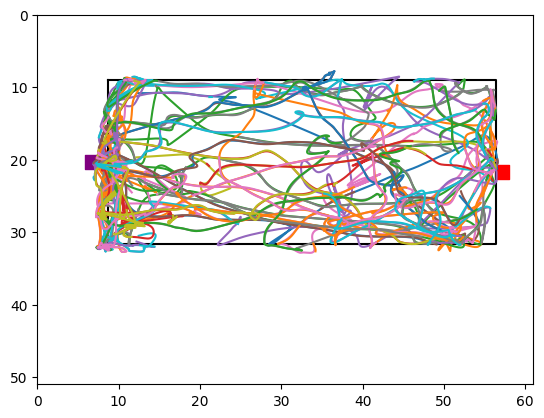

In [293]:
data = train_oa[(train_oa.animal=='J701RT') &(train_oa.date_index==-4) ]
#thresh = data.time.mean()
#data = data[data.time<=thresh]
xmin,xmax = data.arenaTL_x_cm.astype(int).unique()[0],data.arenaTR_x_cm.astype(int).unique()[0]
ymin,ymax = data.arenaTL_y_cm.astype(int).unique()[0] ,data.arenaBL_y_cm.astype(int).unique()[0]

nose_x,nose_y = flatten_list_of_arrays(data.ts_nose_x_cm.to_list()),flatten_list_of_arrays(data.ts_nose_y_cm.to_list())

array ,xedges ,yedges   = np.histogram2d(nose_x.astype(float), nose_y.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))
#array_list.append(array)
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [294]:
(array>0)*1

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

In [295]:
np.sum((array>0)*1)

253

In [316]:
data = train_oa[(train_oa.animal=='G8CK1LT') &(train_oa.date_index==-1) ]
xmin,xmax = data.arenaTL_x_cm.astype(int).unique()[0],data.arenaTR_x_cm.astype(int).unique()[0]
ymin,ymax = data.arenaTL_y_cm.astype(int).unique()[0] ,data.arenaBL_y_cm.astype(int).unique()[0]
array_list = []
for ind,row in data.iterrows():
    array ,xedges ,yedges   = np.histogram2d(row.ts_nose_x_cm.astype(float), row.ts_nose_y_cm.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))
    array_list.append(array)



In [309]:
np.sum((array_list>0)*1)

TypeError: '>' not supported between instances of 'list' and 'int'

In [317]:
sum(array_list).sum()

35593.0

In [308]:
array[0]

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0., 30.,  0.,  2.,  2.,  0.,  0.,  0.])

In [307]:
(array>0)*1

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 0, 0]])

<AxesSubplot: xlabel='date_index', ylabel='linearity'>

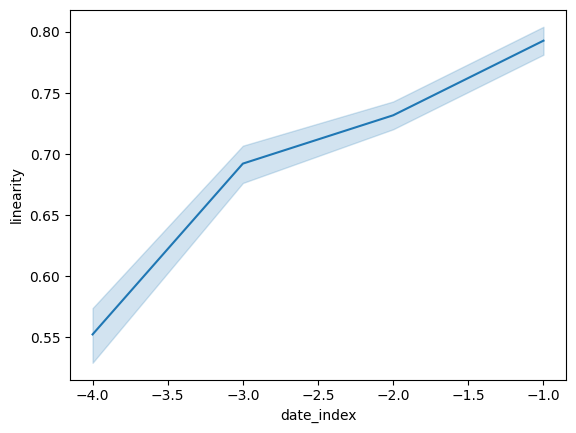

In [359]:
sns.lineplot(data = train_oa,x = 'date_index',y = 'linearity')

<AxesSubplot: xlabel='date_index', ylabel='time'>

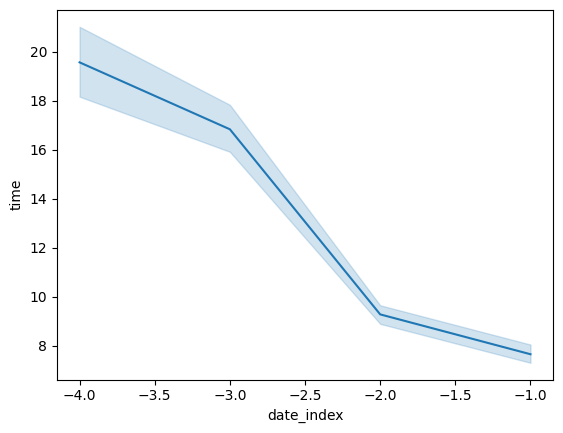

In [431]:
sns.lineplot(data = train_oa,x = 'date_index',y = 'time')

In [335]:
data = train_oa[(train_oa.animal=='J701RT') &(train_oa.date_index==-4)]

In [ ]:
data = train_oa[(train_oa.animal=='J701RT') &(train_oa.date_index==-4)]
data

In [458]:
data = data[data.time<=thresh]

In [460]:
data = train_oa[(train_oa.animal=='J701LT') &(train_oa.date_index==-4)]

In [470]:
data

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,nose_likelihood,leftear_x,...,mean_arenaTR_x_cm,mean_arenaTR_y_cm,mean_arenaBL_x_cm,mean_arenaBL_y_cm,mean_arenaBR_x_cm,mean_arenaBR_y_cm,mean_leftportT_x_cm,mean_leftportT_y_cm,mean_rightportT_x_cm,mean_rightportT_y_cm
6718,0,0,39252.709657,39254.654937,"[39252.725171, 39252.742054, 39252.7595, 39252...","[961, 962, 963, 964, 965, 966, 967, 968, 969, ...","[295.6569728811094, 294.38170640389313, 291.95...","[170.3201259528771, 170.4583035491397, 170.721...","[0.999994158744812, 0.9999971389770508, 0.9999...","[320.31748033268536, 319.04386167211754, 316.6...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6719,1,1,39254.654937,39262.962265,"[39254.659238, 39254.676736, 39254.692659, 392...","[[1077, 1078, 1079, 1080, 1081, 1082, 1083, 10...","[96.48725509973565, 97.13246654145578, 98.4171...","[220.83001978695995, 220.85598052095946, 220.9...","[0.9983112812042236, 0.9899179339408875, 0.992...","[119.13646986882753, 119.86907133413965, 121.2...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6720,2,2,39262.962265,39277.176768,"[39262.978777, 39262.996672, 39263.012864, 392...","[1576, 1577, 1578, 1579, 1580, 1581, 1582, 158...","[110.4213568305765, 110.59066072771846, 110.88...","[242.60060532294253, 242.54188289655215, 242.4...","[0.9803398251533508, 0.9892265796661377, 0.999...","[109.60215608030335, 110.3189104889801, 111.58...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6721,3,3,39277.176768,39330.061132,"[39277.183564, 39277.200422, 39277.2171, 39277...","[[2428, 2429, 2430, 2431, 2432, 2433, 2434, 24...","[650.145263671875, 650.145259228167, 650.14522...","[248.6383056640625, 248.63830208213983, 248.63...","[0.030852390453219414, 0.01779721863567829, 0....","[644.7460906103747, 644.5749496628628, 644.248...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6722,4,4,39330.061132,39341.288742,"[39330.068646, 39330.086323, 39330.102003, 393...","[5600, 5601, 5602, 5603, 5604, 5605, 5606, 560...","[111.99070870268775, 111.99188712797692, 111.9...","[216.95192179662388, 216.914580921148, 216.855...","[0.9999618530273438, 0.9999898672103882, 0.999...","[123.32336637797195, 123.3408907800546, 123.37...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6723,5,5,39341.288742,39359.021772,"[39341.290342, 39341.306022, 39341.322534, 393...","[[6273, 6274, 6275, 6276, 6277, 6278, 6279, 62...","[652.7224731445312, 652.7224731445312, 652.722...","[265.65228271484375, 265.65228271484375, 265.6...","[0.0067152907140553, 0.005044655408710241, 0.0...","[650.6781624566798, 650.514019668435, 650.2080...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6724,6,6,39359.021772,39382.211136,"[39359.028953, 39359.045977, 39359.06208, 3935...","[7337, 7338, 7339, 7340, 7341, 7342, 7343, 734...","[118.37769233054674, 118.29179755215317, 118.1...","[239.01636295386123, 239.1094998994639, 239.27...","[0.9998499155044556, 0.9999781847000122, 0.999...","[128.6566841185097, 128.61000460144425, 128.51...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6725,7,7,39382.211136,39431.851430,"[39382.220083, 39382.236915, 39382.253516, 393...","[[8728, 8729, 8730, 8731, 8732, 8733, 8734, 87...","[648.7777099609375, 648.7777099609375, 648.777...","[249.43940734863284, 249.43940734863284, 249.4...","[0.13011519610881805, 0.06154462322592735, 0.0...","[641.4751229011496, 641.5975764119263, 641.838...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6726,8,8,39431.851430,39457.653580,"[39431.853836, 39431.871705, 39431.887296, 394...","[11705, 11706, 11707, 11708, 11709, 11710, 117...","[114.90475066622074, 114.87207257250448, 114.8...","[221.7928702471043, 221.79646671807532, 221.80...","[0.9998370409011841, 0.9999089241027832, 0.999...","[124.64603798073563, 124.64122333579785, 124.6...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6727,9,9,39457.653580,39468.918476,"[39457.662668, 39457.679385, 39457.696524, 394...","[[13253, 13254, 13255, 13256, 13257, 13258, 13...","[641.962890625, 641.962890625, 641.9

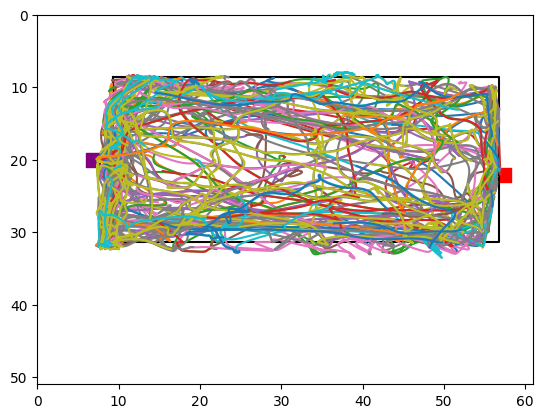

In [476]:
data = train_oa[(train_oa.animal=='J701LT') &(train_oa.date_index==-4)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]
xmin,xmax = data.arenaTL_x_cm.astype(int).unique()[0],data.arenaTR_x_cm.astype(int).unique()[0]
ymin,ymax = data.arenaTL_y_cm.astype(int).unique()[0] ,data.arenaBL_y_cm.astype(int).unique()[0]

nose_x,nose_y = flatten_list_of_arrays(data.ts_nose_x_cm.to_list()),flatten_list_of_arrays(data.ts_nose_y_cm.to_list())

array ,xedges ,yedges   = np.histogram2d(nose_x.astype(float), nose_y.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))
#array_list.append(array)
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [477]:
np.sum((array>0)*1)

1004

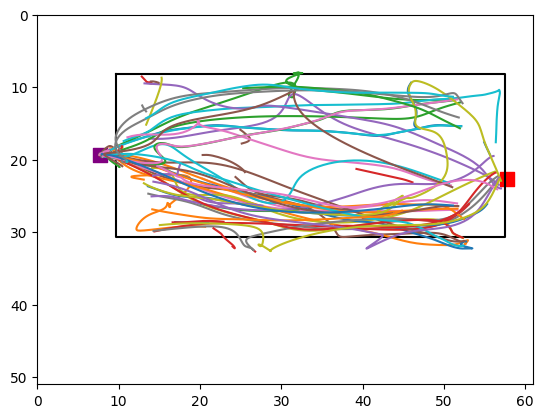

In [479]:
data = train_oa[(train_oa.animal=='J701LT') &(train_oa.date_index==-1)]
thresh = data.time.mean()
data = data[data.time<=thresh].sample(50)
xmin,xmax = data.arenaTL_x_cm.astype(int).unique()[0],data.arenaTR_x_cm.astype(int).unique()[0]
ymin,ymax = data.arenaTL_y_cm.astype(int).unique()[0] ,data.arenaBL_y_cm.astype(int).unique()[0]

nose_x,nose_y = flatten_list_of_arrays(data.ts_nose_x_cm.to_list()),flatten_list_of_arrays(data.ts_nose_y_cm.to_list())

array ,xedges ,yedges   = np.histogram2d(nose_x.astype(float), nose_y.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))
#array_list.append(array)
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [480]:
np.sum((array>0)*1)

732

In [341]:
data = train_oa[(train_oa.animal=='J701RT') &(train_oa.date_index==-1)]

In [342]:
data.time

1734     3.666667
1735     4.083333
1736     4.750000
1737     4.733333
1738     3.766667
          ...    
1995    17.266667
1996    99.050000
1997     8.333333
1998    28.283333
1999     5.000000
Name: time, Length: 266, dtype: float64

In [194]:
array[array <= 60] = 0

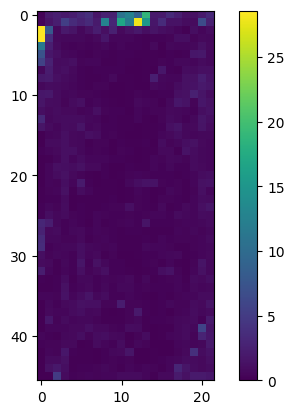

In [478]:
plt.imshow(array/60)
plt.colorbar()

In [482]:
train_oa.odd

0        left
1       right
2        left
3       right
4        left
        ...  
9241    right
9242     left
9243    right
9244     left
9245    right
Name: odd, Length: 9246, dtype: object

In [589]:
def compute_frenchet_distance_training(df,nan_thresh):
    """returns df each row is the average frenchet distance of a cluster by direction, start, animal, and date_index"""
    dictists = {key: [] for key in ['animal','date_index',"trials",'fdist','start','odd']}
    df = df
    for date_id,date_id_df in df.groupby(['date_index']):
        for ani, ani_df in tqdm(date_id_df.groupby(['animal'])):
            for start,start_df in date_id_df.groupby('start'):
                for odd,odd_df in start_df.groupby('odd'):
                    dictists['animal'].append(ani)
                    dictists['date_index'].append(odd_df.date_index.unique()[0])
                    dictists['trials'].append(len(odd_df))
                    dictists['start'].append(odd_df.start.unique()[0])
                    dictists['odd'].append(odd_df.odd.unique()[0])
                    if len(odd_df) >=4:
                        sl, matx, maty = create_streamlines(odd_df,'ts_nose_x_cm','ts_nose_y_cm')
                        fdist_avg = []
                        for i,row in enumerate(sl):
                            if sum(np.isnan(row[:,0])) >= nan_thresh:
                                #print('above nan thresh')
                                continue
                            else:
                                fdist_list = []

                    
                            for traj in sl:
                                if sum(np.isnan(traj[:,0]))>= nan_thresh:
                                    #print('above nan thresh')
                                    continue
                                else: 
                                    avg_fdist = frdist(sl[i],traj)
                                    fdist_list.append(avg_fdist)
                            fdist_avg.append(np.nanmean(fdist_list))
                        dictists['fdist'].append(np.mean(fdist_avg))
                    else:
                        dictists['fdist'].append(np.nan)
    f_dist_df = pd.DataFrame.from_dict(dictists)
    return f_dist_df

In [ ]:
train_oa[(train_oa.animal=='G8CKRT') &(train_oa.date_index==-1) ]

In [572]:
nan_thresh = 10
for i,row in enumerate(sl):
    if sum(np.isnan(row[:,0])) >= nan_thresh:
        print('above nan thresh')
        continue


above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh


In [581]:
train_oa[(train_oa.animal=='G8CKRT') &(train_oa.date_index==-1) ]

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,nose_likelihood,leftear_x,...,mean_arenaTR_x_cm,mean_arenaTR_y_cm,mean_arenaBL_x_cm,mean_arenaBL_y_cm,mean_arenaBR_x_cm,mean_arenaBR_y_cm,mean_leftportT_x_cm,mean_leftportT_y_cm,mean_rightportT_x_cm,mean_rightportT_y_cm
5102,2596,0,50247.852441,50249.396800,"[50247.865958, 50247.882073, 50247.898931, 502...","[72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 8...","[675.0280151367189, 675.0280151367189, 675.028...","[254.61351013183594, 254.61351013183594, 254.6...","[0.06801322847604752, 0.061899758875370026, 0....","[674.3634325810413, 674.3855603835425, 674.425...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5103,2597,1,50249.396800,50254.156761,"[50249.399078, 50249.415961, 50249.432896, 502...","[[164, 165, 166, 167, 168, 169, 170, 171, 172,...","[674.8306274414062, 674.8306245551744, 674.830...","[271.7885437011719, 271.78854871259625, 271.78...","[0.4414965808391571, 0.5344058275222778, 0.503...","[677.5368691664975, 677.5476629547716, 677.565...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5104,2598,2,50254.156761,50258.576665,"[50254.167488, 50254.184921, 50254.200704, 502...","[450, 451, 452, 453, 454, 455, 456, 457, 458, ...","[108.22493185366221, 108.14825201945754, 108.0...","[258.8528146564046, 258.84789445172737, 258.84...","[0.8622837662696838, 0.9034079313278198, 0.942...","[122.27672845973808, 122.24343876222807, 122.1...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5105,2599,3,50258.576665,50262.300288,"[50258.585484, 50258.602163, 50258.619814, 502...","[[715, 716, 717, 718, 719, 720, 721, 722, 723,...","[674.6126708984375, 674.6126708984375, 674.612...","[250.88551330566403, 250.88551330566403, 250.8...","[0.2774178385734558, 0.1592460423707962, 0.164...","[672.4481660848379, 672.6168494393683, 672.927...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5106,2600,4,50262.300288,50265.794432,"[50262.303347, 50262.320153, 50262.33792, 5026...","[938, 939, 940, 941, 942, 943, 944, 945, 946, ...","[111.37246704101562, 111.37246704101562, 111.3...","[243.02639770507812, 243.02639770507812, 243.0...","[0.14326253533363342, 0.1265486776828766, 0.06...","[120.78631829981003, 120.79673617600778, 120.8...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5421,2915,76,50662.320934,50671.206067,"[50662.325542, 50662.342553, 50662.360025, 506...","[24931, 24932, 24933, 24934, 24935, 24936, 249...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.036269091069698334, 0.03375899791717529, 0....","[116.63301086425781, 116.31688690185547, 116.0...",...,55.484796,7.094737,5.869629,33.531281,56.115563,33.883896,8.229576,19.839667,54.418193,20.482844
5422,2916,77,50671.206067,50709.892812,"[50671.212147, 50671.2288, 50671.245337, 50671...","[[25464, 25465, 25466, 25467, 25468, 25469, 25...","[nan, 679.8357543945312, 680.8103637695312, 68...","[nan, 257.6959533691406, 257.5067138671875, 25...","[0.741727888584137, 0.8461090922355652, 0.8360...","[673.495849609375, 673.2891845703125, 674.0415...",...,55.484796,7.094737,5.869629,33.531281,56.115563,33.883896,8.229576,19.839667,54.418193,20.482844
5423,2917,78,50709.892812,50727.432332,"[50709.909222, 50709.925478, 50709.94222, 5070...","[27785, 27786, 27787, 27788, 27789, 27790, 277...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.07963050156831741, 0.06094793230295181, 0.0...","[119.4471206665039, 118.82313537597656, 118.76...",...,55.484796,7.094737,5.869629,33.531281,56.115563,33.883896,8.229576,19.839667,54.418193,20.482844
5424,2918,79,50727.432332,50852.776588,"[50727.448345, 50727.465036, 50727.481676, 507...","[[28837, 28838, 28839, 28840, 28841, 28842, 28...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.4976229965686798, 0.4115322828

In [570]:
sl, matx, maty = create_streamlines(train_oa[(train_oa.animal=='G8CKRT') &(train_oa.date_index==-1) ],'ts_nose_x_cm','ts_nose_y_cm')

In [582]:
f_dist_df_train = compute_frenchet_distance_training(train_oa[(train_oa.animal=='G8CKRT') &(train_oa.date_index==-1) ],10)

100%|██████████| 2/2 [06:59<00:00, 209.54s/it]


In [591]:
f_dist_df_train = compute_frenchet_distance_training(train_oa,5)

  0%|          | 0/13 [12:29<?, ?it/s]


KeyboardInterrupt: 

In [575]:
f_dist_df_train

,animal,date_index,trials,fdist,start,odd
0,G8CKRT,-4.0,38,5.316097,bottom,left
1,G8CKRT,-4.0,38,10.741529,bottom,right
2,G8CKRT,-4.0,36,6.137701,top,left
3,G8CKRT,-4.0,38,7.069049,top,right


In [574]:
f_dist_df_train = compute_frenchet_distance_training(train_oa[(train_oa.animal=='G8CKRT') &(train_oa.date_index==-4) ],10)

  0%|          | 0/2 [00:00<?, ?it/s]

above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thre

 50%|█████     | 1/2 [00:56<00:56, 56.39s/it]

above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thresh
above nan thre

100%|██████████| 2/2 [01:47<00:00, 53.64s/it]

above nan thresh
above nan thresh


In [ ]:
def compute_arena_occupancy(,samples)

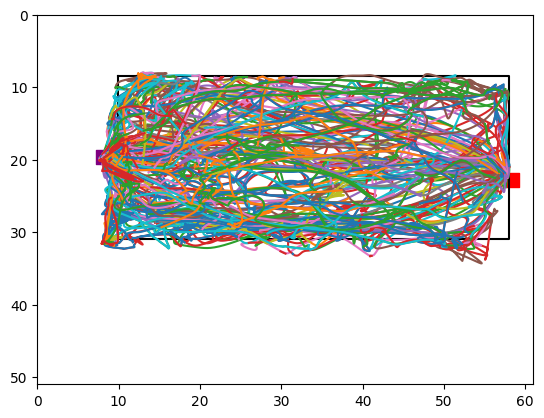

In [ ]:
data = train_oa[(train_oa.animal=='J701RT') &(train_oa.date_index==-1) &(train_oa.odd=='left')]
xmin,xmax = data.arenaTL_x_cm.astype(int).unique()[0],data.arenaTR_x_cm.astype(int).unique()[0]
ymin,ymax = data.arenaTL_y_cm.astype(int).unique()[0] ,data.arenaBL_y_cm.astype(int).unique()[0]

nose_x,nose_y = flatten_list_of_arrays(data.ts_nose_x_cm.to_list()),flatten_list_of_arrays(data.ts_nose_y_cm.to_list())

array ,xedges ,yedges   = np.histogram2d(nose_x.astype(float), nose_y.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,1)), list(range(ymin,ymax,1)),))
#array_list.append(array)
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))


In [140]:
np.sum((array>0)*1)

1081

In [86]:
np.where(array_list[0]>0)

(array([ 2,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 18, 19, 20, 21, 22, 23], dtype=int64),
 array([ 7,  8,  8,  9,  9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
         9, 10,  9,  9,  9,  8,  8], dtype=int64))

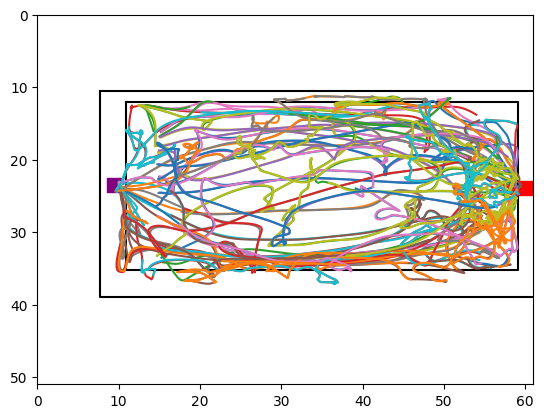

In [160]:
data = train_oa[(train_oa.animal=='G8CK1LT') &(train_oa.date_index==-4) ]
fig,ax = plt.subplots()

plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

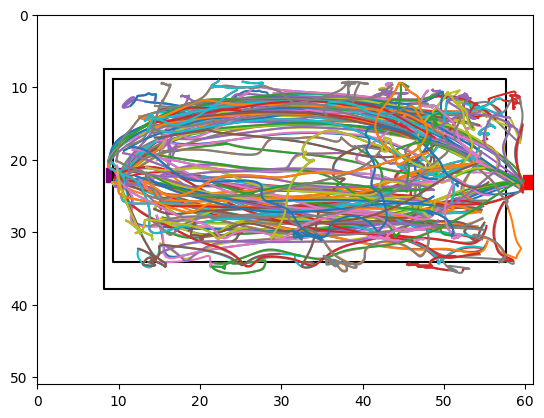

In [161]:
data = train_oa[(train_oa.animal=='G8CKLT') &(train_oa.date_index==-1) ]
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

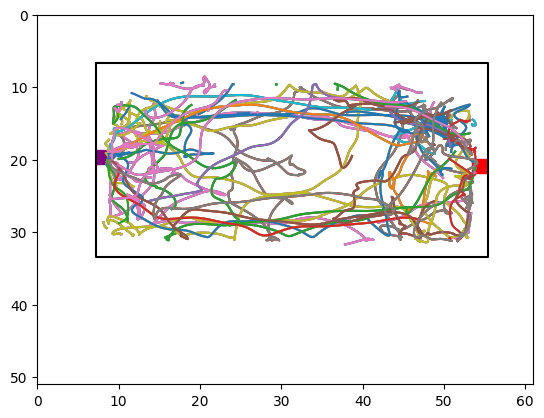

In [28]:
data = train_oa[(train_oa.animal=='G8CKLT') &(train_oa.date_index==-4) ]
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

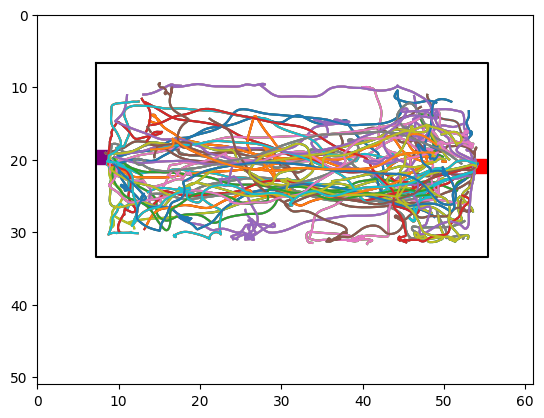

In [583]:
data = train_oa[(train_oa.animal=='G8CKRT') &(train_oa.date_index==-4) ]
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

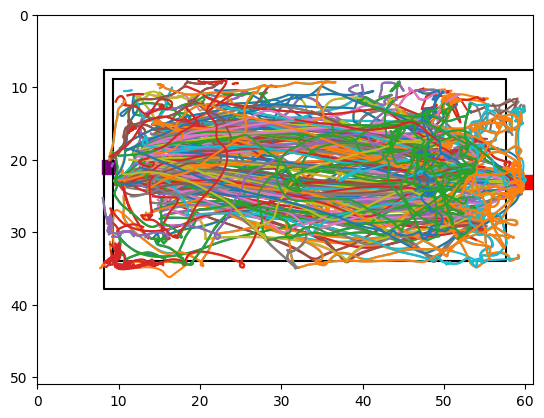

In [586]:
data = train_oa[(train_oa.animal=='G8CKRT') &(train_oa.date_index==-1) ]
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

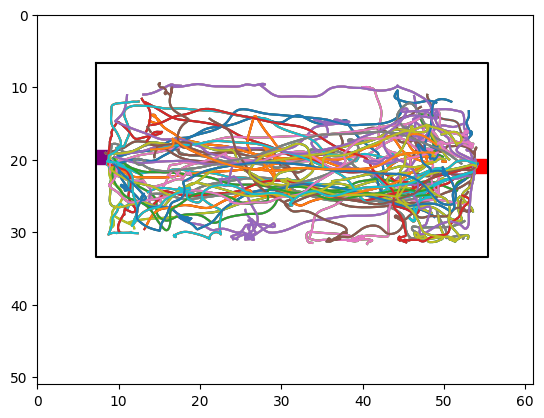

In [587]:
data = train_oa[(train_oa.animal=='G8CKRT') &(train_oa.date_index==-4) ]
fig,ax = plt.subplots()
plot_arena(data,ax,outer=True)
for ind, row in data.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))